# Projekat 3 - Veštačka neuronska mreža

## Preprocesiranje

### Importovanje biblioteka

In [446]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import math

import re
import nltk
from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Conv1D, GlobalMaxPooling1D, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


### Učitavanje podataka

In [447]:
df=pd.read_csv("sentimentdataset.csv")
df

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


### Uklanjanje nepotrebnih kolona i izmena postojećih vrednosti

In [448]:
df = df.drop(columns=["Unnamed: 0.1"])
df = df.drop(columns=["Unnamed: 0"])
df = df.drop(columns=["Timestamp"])
df['Country'] = df['Country'].str.strip().replace('USA', 'United States')
df['Platform'] = df['Platform'].str.strip().replace('Twitter', 'X')
df

,Text,Sentiment,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,User123,X,#Nature #Park,15.0,30.0,United States,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,CommuterX,X,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,United States,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,Attending a surprise birthday party organized ...,Happy,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,United States,2018,6,22,14
729,Successfully fundraising for a school charity ...,Happy,CharityFundraisingTriumphHighSchool,X,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,"Participating in a multicultural festival, cel...",Happy,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


### Dimenzije dataset-a

In [449]:
df.shape

(732, 12)

In [450]:
df.columns.tolist()

['Text',
 'Sentiment',
 'User',
 'Platform',
 'Hashtags',
 'Retweets',
 'Likes',
 'Country',
 'Year',
 'Month',
 'Day',
 'Hour']

### Prikaz kolona

#### Prikaz prvih 5 redova

In [451]:
df.head()

,Text,Sentiment,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,User123,X,#Nature #Park,15.0,30.0,United States,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,CommuterX,X,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,United States,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


#### Prikaz zadnjih 5 redova

In [452]:
df.tail()

,Text,Sentiment,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
727,Collaborating on a science project that receiv...,Happy,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,Attending a surprise birthday party organized ...,Happy,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,United States,2018,6,22,14
729,Successfully fundraising for a school charity ...,Happy,CharityFundraisingTriumphHighSchool,X,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,"Participating in a multicultural festival, cel...",Happy,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20
731,Organizing a virtual talent show during challe...,Happy,VirtualTalentShowSuccessHighSchool,Instagram,#VirtualEntertainment #HighSchoolPositivity,24.0,47.0,United States,2020,11,15,15


### Opis atributa dataset-a

### Prikaz tipova podataka

In [453]:
df.dtypes

Text          object
Sentiment     object
User          object
Platform      object
Hashtags      object
Retweets     float64
Likes        float64
Country       object
Year           int64
Month          int64
Day            int64
Hour           int64
dtype: object

### Prikaz informacija o podacima

In [454]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Text       732 non-null    object 
 1   Sentiment  732 non-null    object 
 2   User       732 non-null    object 
 3   Platform   732 non-null    object 
 4   Hashtags   732 non-null    object 
 5   Retweets   732 non-null    float64
 6   Likes      732 non-null    float64
 7   Country    732 non-null    object 
 8   Year       732 non-null    int64  
 9   Month      732 non-null    int64  
 10  Day        732 non-null    int64  
 11  Hour       732 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 68.8+ KB


### Provera da li postoje nedostajuće vrednosti

In [455]:
df.isna().sum()

Text         0
Sentiment    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

### Provera da li postoje duplikati

In [456]:
duplicates=df.duplicated()
duplicates

0      False
1      False
2      False
3      False
4      False
       ...  
727    False
728    False
729    False
730    False
731    False
Length: 732, dtype: bool

In [457]:
print(f"Broj duplikata je: {df.duplicated().sum()}")

Broj duplikata je: 20


##### Brisanje duplikata

In [458]:
df = df.drop_duplicates()
print(f"Broj duplikata je: {df.duplicated().sum()}")

Broj duplikata je: 0


### Statistički opis

In [459]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Retweets,712.0,21.542135,7.124840,5.0,17.75,22.0,25.0,40.0
Likes,712.0,42.966292,14.215995,10.0,34.75,43.0,50.0,80.0
Year,712.0,2020.476124,2.828326,2010.0,2019.00,2021.0,2023.0,2023.0
Month,712.0,6.108146,3.406099,1.0,3.00,6.0,9.0,12.0
Day,712.0,15.514045,8.444895,1.0,10.00,15.0,22.0,31.0
Hour,712.0,15.592697,4.062778,0.0,13.00,16.0,19.0,23.0


In [460]:
df.describe(include="O")

,Text,Sentiment,User,Platform,Hashtags,Country
count,712,712,712,712,712,712
unique,707,279,685,3,697,33
top,"A compassionate rain, tears of empathy fallin...",Positive,DreamMosaic,Instagram,#Hopeful #SeedsOfOptimism,United States
freq,2,44,2,252,2,184


In [461]:
df["Country"].value_counts()

Country
United States     184
UK                140
Canada            132
Australia          70
India              68
Brazil             17
France             16
Japan              15
Germany            14
Italy              11
South Africa        6
Greece              5
Spain               5
Netherlands         4
Sweden              2
Portugal            2
Switzerland         2
Belgium             2
Denmark             2
Czech Republic      2
Austria             1
Jordan              1
Peru                1
Maldives            1
China               1
Cambodia            1
Norway              1
Colombia            1
Ireland             1
Jamaica             1
Kenya               1
Scotland            1
Thailand            1
Name: count, dtype: int64

#### Distribucija kategorijskih vrednosti

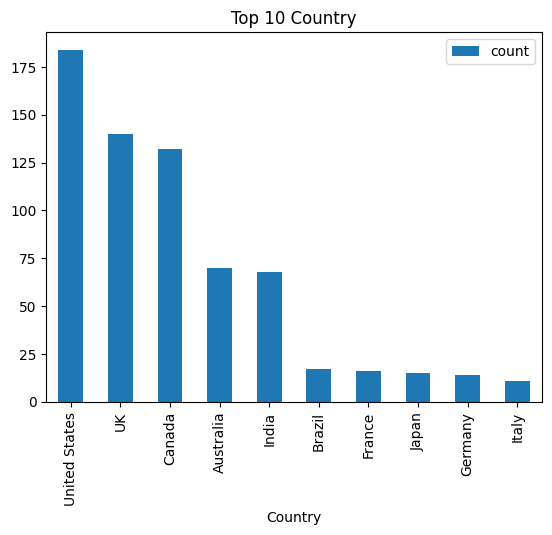

In [462]:
df['Country'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Country')
plt.legend()
plt.show()

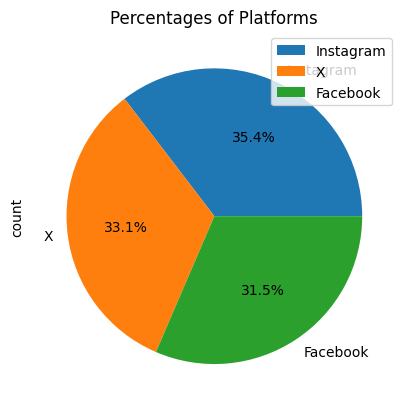

In [463]:
df['Platform'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentages of Platforms')
plt.legend()
plt.show()

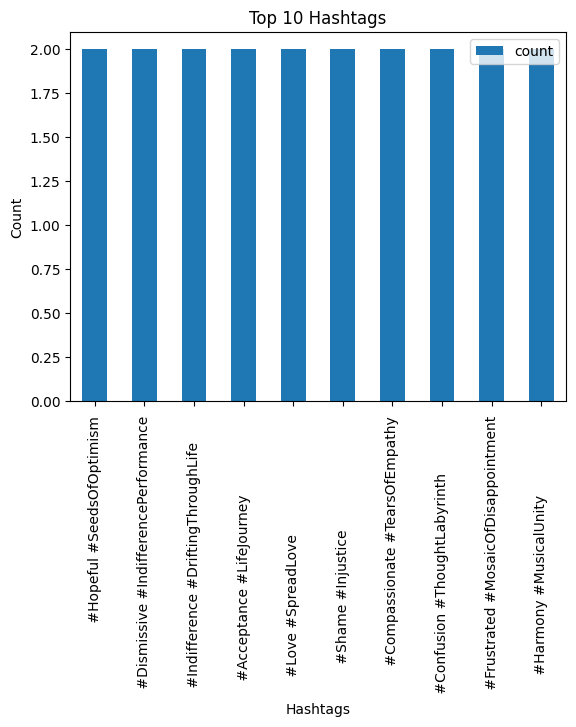

In [464]:
df['Hashtags'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Hashtags')
plt.xlabel('Hashtags')
plt.ylabel('Count')
plt.legend()
plt.show()

In [465]:
hourly_activity = df.groupby(['Country', 'Hour']).size().reset_index(name='Num_Posts')
hourly_activity.head(20)

,Country,Hour,Num_Posts
0,Australia,3,1
1,Australia,7,3
2,Australia,8,2
3,Australia,10,7
4,Australia,11,7
5,Australia,12,4
6,Australia,13,3
7,Australia,14,8
8,Australia,15,3
9,Australia,16,7


In [466]:
df.groupby(["User","Sentiment"]).size()

User                    Sentiment       
AbyssOfTime             LostLove            1
AcceptanceSeeker        Acceptance          1
AdeleConcertGoer        Emotion             1
AdeleMelodyTearjerker   Emotion             1
AdventureAwaits         Arousal             1
                                           ..
YearbookExplorer        Nostalgia           1
ZenLifestyle            Acceptance          1
ZenMaster               Calmness            1
ZenMaster2              Serenity            1
ZenSeeker               Mindfulness         1
Length: 705, dtype: int64

In [467]:
df["Likes"].agg(["max","min","mean"])

max     80.000000
min     10.000000
mean    42.966292
Name: Likes, dtype: float64

In [468]:
monthly_activity = df.groupby(['Country', 'Month']).size().reset_index(name='Num_Posts')
monthly_activity.head(10)

,Country,Month,Num_Posts
0,Australia,1,7
1,Australia,2,12
2,Australia,3,6
3,Australia,4,4
4,Australia,5,5
5,Australia,6,7
6,Australia,7,3
7,Australia,8,7
8,Australia,9,6
9,Australia,10,4


In [469]:
yearly_activity = df.groupby(['Country', 'Year']).size().reset_index(name='Num_Posts')
yearly_activity.head(10)

,Country,Year,Num_Posts
0,Australia,2010,1
1,Australia,2012,2
2,Australia,2015,4
3,Australia,2016,1
4,Australia,2017,8
5,Australia,2018,6
6,Australia,2019,10
7,Australia,2020,7
8,Australia,2021,6
9,Australia,2022,11


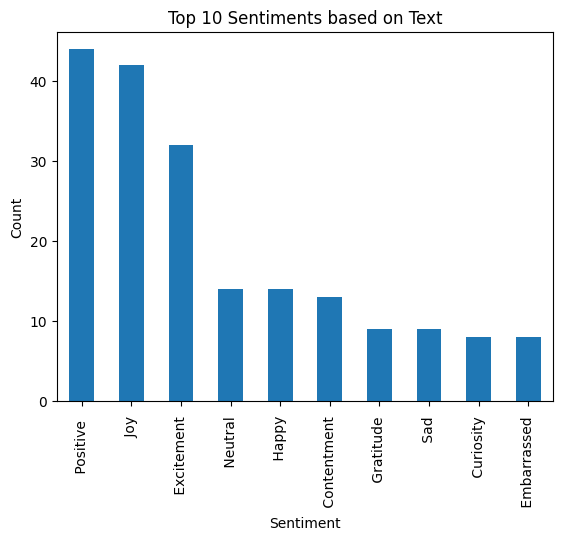

In [470]:
df['Sentiment'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Sentiments based on Text')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

#### Sređivanje kolone Sentiment

In [471]:
df = df.copy()

df["Sentiment"] = df["Sentiment"].astype(str).str.strip()
df["Sentiment"]

0      Positive
1      Negative
2      Positive
3      Positive
4       Neutral
         ...   
727       Happy
728       Happy
729       Happy
730       Happy
731       Happy
Name: Sentiment, Length: 712, dtype: object

In [472]:
print("Broj različitih sentiment oznaka:", df["Sentiment"].nunique())
print(sorted(df["Sentiment"].unique()))

Broj različitih sentiment oznaka: 191
['Acceptance', 'Accomplishment', 'Admiration', 'Adoration', 'Adrenaline', 'Adventure', 'Affection', 'Amazement', 'Ambivalence', 'Amusement', 'Anger', 'Anticipation', 'Anxiety', 'Appreciation', 'Apprehensive', 'Arousal', 'ArtisticBurst', 'Awe', 'Bad', 'Betrayal', 'Bitter', 'Bitterness', 'Bittersweet', 'Blessed', 'Boredom', 'Breakthrough', 'Calmness', 'Captivation', 'Celebration', 'Celestial Wonder', 'Challenge', 'Charm', 'Colorful', 'Compassion', 'Compassionate', 'Confidence', 'Confident', 'Confusion', 'Connection', 'Contemplation', 'Contentment', 'Coziness', 'Creative Inspiration', 'Creativity', 'Culinary Adventure', 'CulinaryOdyssey', 'Curiosity', 'Darkness', 'Dazzle', 'Desolation', 'Despair', 'Desperation', 'Determination', 'Devastated', 'Disappointed', 'Disappointment', 'Disgust', 'Dismissive', 'DreamChaser', 'Ecstasy', 'Elation', 'Elegance', 'Embarrassed', 'Emotion', 'EmotionalStorm', 'Empathetic', 'Empowerment', 'Enchantment', 'Energy', 'Engag

In [473]:
positive_labels = {
    'Acceptance', 'Accomplishment', 'Admiration', 'Adoration', 'Adrenaline',
    'Adventure', 'Affection', 'Amazement', 'Amusement', 'Anticipation',
    'Appreciation', 'Arousal', 'ArtisticBurst', 'Awe', 'Blessed',
    'Breakthrough', 'Captivation', 'Celebration', 'Celestial Wonder',
    'Charm', 'Colorful', 'Compassion', 'Compassionate', 'Confidence',
    'Confident', 'Connection', 'Contentment', 'Coziness',
    'Creative Inspiration', 'Creativity', 'Culinary Adventure',
    'CulinaryOdyssey', 'Dazzle', 'Determination', 'DreamChaser', 'Ecstasy',
    'Elation', 'Elegance', 'Empathetic', 'Empowerment', 'Enchantment',
    'Energy', 'Engagement', 'Enjoyment', 'Enthusiasm',
    'Envisioning History', 'Euphoria', 'Excitement', 'Exploration',
    'FestiveJoy', 'Free-spirited', 'Freedom', 'Friendship', 'Fulfillment',
    'Grandeur', 'Grateful', 'Gratitude', 'Happiness', 'Happy', 'Harmony',
    'Heartwarming', 'Hope', 'Hopeful', 'Hypnotic', 'Iconic', 'Imagination',
    'Immersion', 'Inspiration', 'Inspired', 'Joy', 'Joy in Baking',
    'JoyfulReunion', 'Kind', 'Kindness', 'Love', 'Marvel', 'Melodic',
    'Mesmerizing', 'Motivation', "Nature's Beauty", "Ocean's Freedom",
    'Optimism', 'Overjoyed', 'Playful', 'PlayfulJoy', 'Positive',
    'Positivity', 'Pride', 'Proud', 'Radiance', 'Rejuvenation', 'Relief',
    'Renewed Effort', 'Resilience', 'Reverence', 'Romance',
    'Runway Creativity', 'Satisfaction', 'Serenity', 'Solace', 'Spark',
    'Success', 'Tenderness', 'Thrill', 'Thrilling Journey', 'Touched',
    'Tranquility', 'Triumph', 'Vibrancy', 'Whimsy', 'Winter Magic',
    'Wonder', 'Wonderment', 'Zest'
}

negative_labels = {
    'Anger', 'Anxiety', 'Apprehensive', 'Bad', 'Betrayal', 'Bitter',
    'Bitterness', 'Boredom', 'Darkness', 'Desolation', 'Despair',
    'Desperation', 'Devastated', 'Disappointed', 'Disappointment',
    'Disgust', 'Dismissive', 'Embarrassed', 'EmotionalStorm', 'Envious',
    'Envy', 'Exhaustion', 'Fear', 'Fearful', 'Frustrated', 'Frustration',
    'Grief', 'Hate', 'Heartache', 'Heartbreak', 'Helplessness',
    'Intimidation', 'Isolation', 'Jealous', 'Jealousy', 'Loneliness',
    'Loss', 'LostLove', 'Melancholy', 'Miscalculation', 'Negative',
    'Numbness', 'Obstacle', 'Overwhelmed', 'Pressure', 'Regret',
    'Resentment', 'Ruins', 'Sad', 'Sadness', 'Shame', 'Sorrow',
    'Suffering', 'Yearning'
}

neutral_labels = {
    'Ambivalence', 'Bittersweet', 'Calmness', 'Challenge', 'Confusion',
    'Contemplation', 'Curiosity', 'Emotion', 'Indifference',
    'InnerJourney', 'Intrigue', 'Journey', 'Mindfulness', 'Mischievous',
    'Neutral', 'Nostalgia', 'Pensive', 'Reflection', 'Solitude',
    'Surprise', 'Suspense', 'Sympathy', 'Whispers of the Past'
}

In [474]:
sentiment_map = {}

for label in positive_labels:
    sentiment_map[label] = "Positive"

for label in negative_labels:
    sentiment_map[label] = "Negative"

for label in neutral_labels:
    sentiment_map[label] = "Neutral"

df["Sentiment_Group"] = df["Sentiment"].map(sentiment_map)

In [475]:
unmapped = sorted(df.loc[df["Sentiment_Group"].isna(), "Sentiment"].unique())

print("Nemapirani sentimenti:", unmapped)
print("Broj nemapiranih:", len(unmapped))

Nemapirani sentimenti: []
Broj nemapiranih: 0


In [476]:
df["Sentiment_Group"].value_counts()

Sentiment_Group
Positive    430
Negative    186
Neutral      96
Name: count, dtype: int64

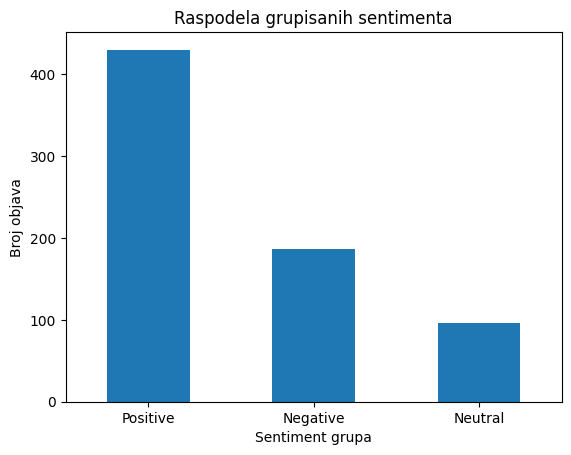

In [477]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment_Group"].value_counts()

sentiment_counts.plot(kind="bar")
plt.title("Raspodela grupisanih sentimenta")
plt.xlabel("Sentiment grupa")
plt.ylabel("Broj objava")
plt.xticks(rotation=0)
plt.show()

#### Procentualna raspodela sentiment grupa

In [478]:
sentiment_percent = df["Sentiment_Group"].value_counts(normalize=True) * 100
print(sentiment_percent.round(2))

Sentiment_Group
Positive    60.39
Negative    26.12
Neutral     13.48
Name: proportion, dtype: float64


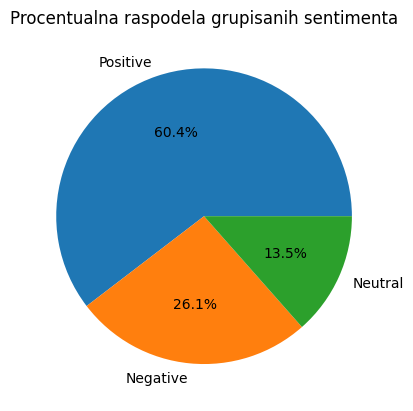

In [479]:
sentiment_percent.plot(kind="pie", autopct="%1.1f%%")
plt.title("Procentualna raspodela grupisanih sentimenta")
plt.ylabel("")
plt.show()

#### Broj reči po grupi sentimenta

In [480]:
df = df.copy()
df["Text_Length"] = df["Text"].str.len()
df["Word_Count"] = df["Text"].str.split().str.len()
df["Hashtag_Count"] = df["Hashtags"].str.count('#')
df.head()

,Text,Sentiment,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_Group,Text_Length,Word_Count,Hashtag_Count
0,Enjoying a beautiful day at the park! ...,Positive,User123,X,#Nature #Park,15.0,30.0,United States,2023,1,15,12,Positive,52,7,2
1,Traffic was terrible this morning. ...,Negative,CommuterX,X,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,Negative,52,5,2
2,Just finished an amazing workout! 💪 ...,Positive,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,United States,2023,1,15,15,Positive,51,6,2
3,Excited about the upcoming weekend getaway! ...,Positive,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,Positive,52,6,2
4,Trying out a new recipe for dinner tonight. ...,Neutral,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,Neutral,52,8,2


In [481]:
df.groupby("Sentiment_Group")["Word_Count"].describe()

,count,mean,std,min,25%,50%,75%,max
Sentiment_Group,,,,,,,,
Negative,186.0,13.204301,4.841396,4.0,9.00,13.0,17.0,25.0
Neutral,96.0,13.697917,4.036986,6.0,10.75,14.0,16.0,24.0
Positive,430.0,12.897674,5.006638,4.0,8.00,12.0,17.0,25.0


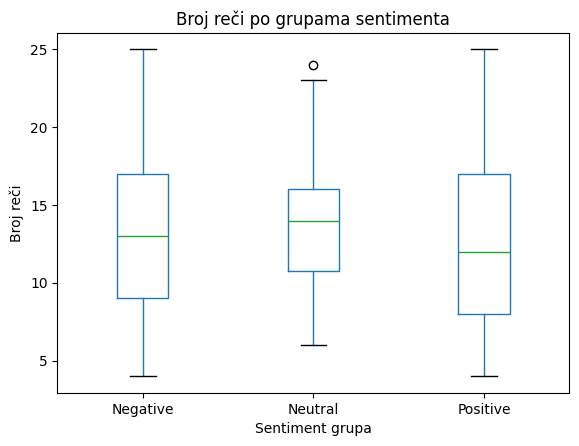

In [482]:
df.boxplot(column="Word_Count", by="Sentiment_Group", grid=False)
plt.title("Broj reči po grupama sentimenta")
plt.suptitle("")
plt.xlabel("Sentiment grupa")
plt.ylabel("Broj reči")
plt.show()

#### Dužina teksta po grupama sentimenta

In [483]:
df.groupby("Sentiment_Group")["Text_Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Sentiment_Group,,,,,,,,
Negative,186.0,85.037634,28.155431,52.0,59.25,81.0,99.75,146.0
Neutral,96.0,91.656250,24.629819,52.0,68.00,93.0,103.25,151.0
Positive,430.0,86.620930,30.055474,50.0,57.00,81.0,108.50,157.0


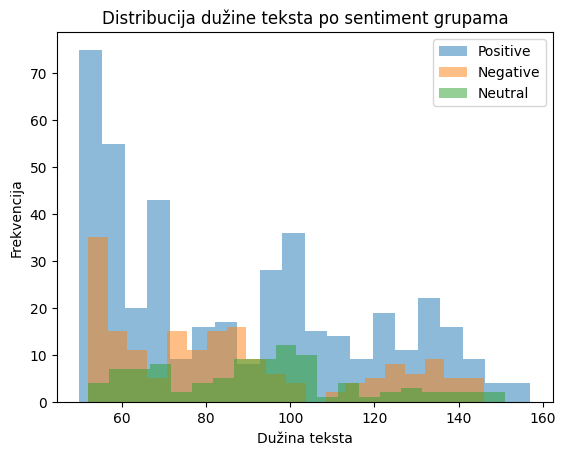

In [484]:
for group in df["Sentiment_Group"].unique():
    df[df["Sentiment_Group"] == group]["Text_Length"].plot(kind="hist", alpha=0.5, bins=20)

plt.title("Distribucija dužine teksta po sentiment grupama")
plt.xlabel("Dužina teksta")
plt.ylabel("Frekvencija")
plt.legend(df["Sentiment_Group"].unique())
plt.show()

#### Sentiment po platformi

In [485]:
platform_sentiment = pd.crosstab(df["Platform"], df["Sentiment_Group"])
platform_sentiment

Sentiment_Group,Negative,Neutral,Positive
Platform,,,
Facebook,57,29,138
Instagram,63,38,151
X,66,29,141


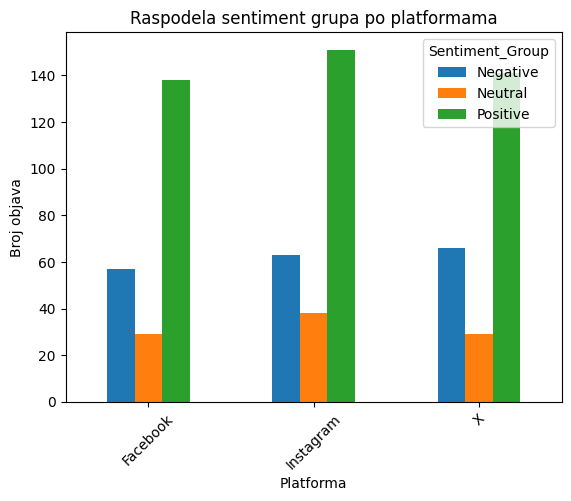

In [486]:
platform_sentiment.plot(kind="bar")
plt.title("Raspodela sentiment grupa po platformama")
plt.xlabel("Platforma")
plt.ylabel("Broj objava")
plt.xticks(rotation=45)
plt.show()

#### Sentiment po državama

In [487]:
country_sentiment = pd.crosstab(df["Country"], df["Sentiment_Group"])
country_sentiment.head(10)

Sentiment_Group,Negative,Neutral,Positive
Country,,,
Australia,21,11,38
Austria,0,0,1
Belgium,0,0,2
Brazil,6,0,11
Cambodia,0,0,1
Canada,38,16,78
China,0,0,1
Colombia,0,0,1
Czech Republic,0,0,2


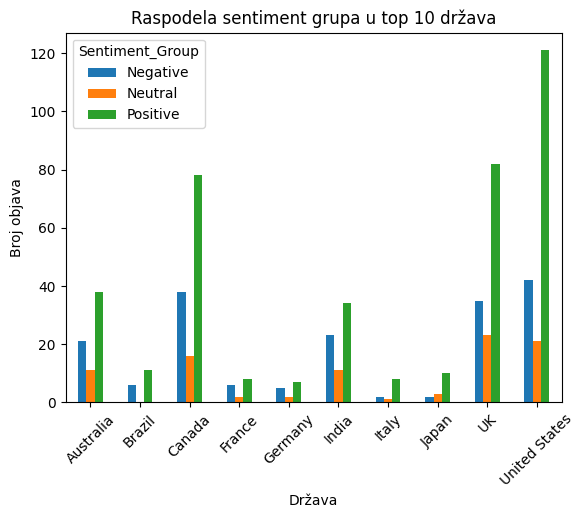

In [488]:
top_countries = df["Country"].value_counts().head(10).index
country_sentiment_top = pd.crosstab(
    df[df["Country"].isin(top_countries)]["Country"],
    df[df["Country"].isin(top_countries)]["Sentiment_Group"]
)

country_sentiment_top.plot(kind="bar")
plt.title("Raspodela sentiment grupa u top 10 država")
plt.xlabel("Država")
plt.ylabel("Broj objava")
plt.xticks(rotation=45)
plt.show()

### Distribucija numeričkih kolona

In [489]:
numerical_columns = df[['Day', 'Month', 'Year', 'Likes', 'Retweets']]

for col in numerical_columns.columns:
    print(f"Minimum {col}: {df[col].min()} | Maximum {col}: {df[col].max()}")

Minimum Day: 1 | Maximum Day: 31
Minimum Month: 1 | Maximum Month: 12
Minimum Year: 2010 | Maximum Year: 2023
Minimum Likes: 10.0 | Maximum Likes: 80.0
Minimum Retweets: 5.0 | Maximum Retweets: 40.0


### Zavisnost izmedju atributa

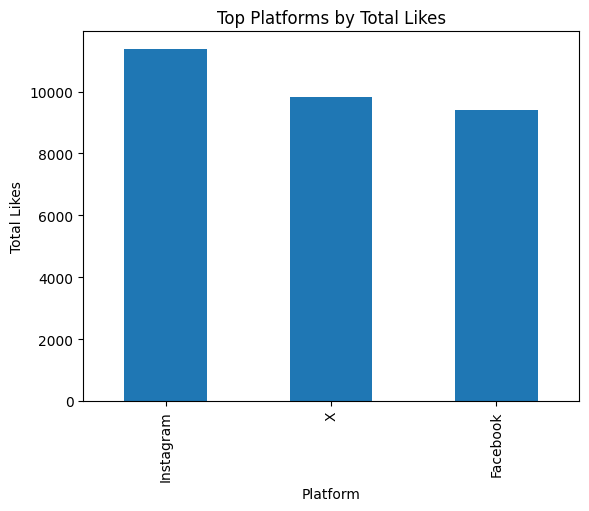

In [490]:
top_likes_platform = df.groupby('Platform')['Likes'].sum().nlargest(10)
top_likes_platform.plot(kind='bar')
plt.title('Top Platforms by Total Likes')
plt.xlabel('Platform')
plt.ylabel('Total Likes')
plt.show()

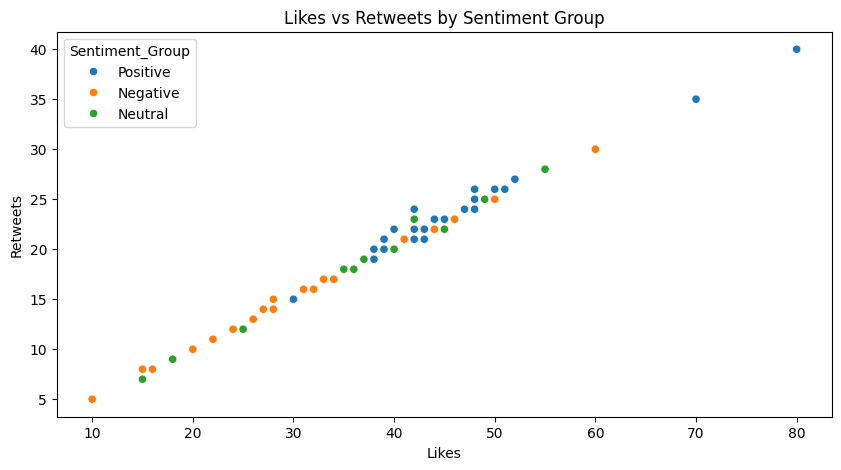

In [491]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Likes", y="Retweets", hue="Sentiment_Group", data=df)
plt.title("Likes vs Retweets by Sentiment Group")
plt.show()

In [492]:
df.groupby("Text")[["Sentiment", "Sentiment_Group"]].sum().reset_index()

,Text,Sentiment,Sentiment_Group
0,A bitter experience turned into a valuable le...,Bitter,Negative
1,"A compassionate rain, tears of empathy fallin...",CompassionateCompassionate,PositivePositive
2,A cozy evening with a good movie. ...,Positive,Positive
3,"A fiery determination burning within, fueled ...",Determination,Positive
4,"A free spirit soaring on the wings of dreams,...",Free-spirited,Positive
...,...,...,...
702,Witnessed a heated argument in the cafeteria. ...,Hate,Negative
703,Witnessing a heartwarming comeback in the hock...,Heartwarming,Positive
704,"Witnessing a record-breaking marathon, spectat...",Admiration,Positive
705,Wonderment at the beauty of a double rainbow a...,Wonderment,Positive


#### Distribucija kolona

<Figure size 1200x800 with 0 Axes>

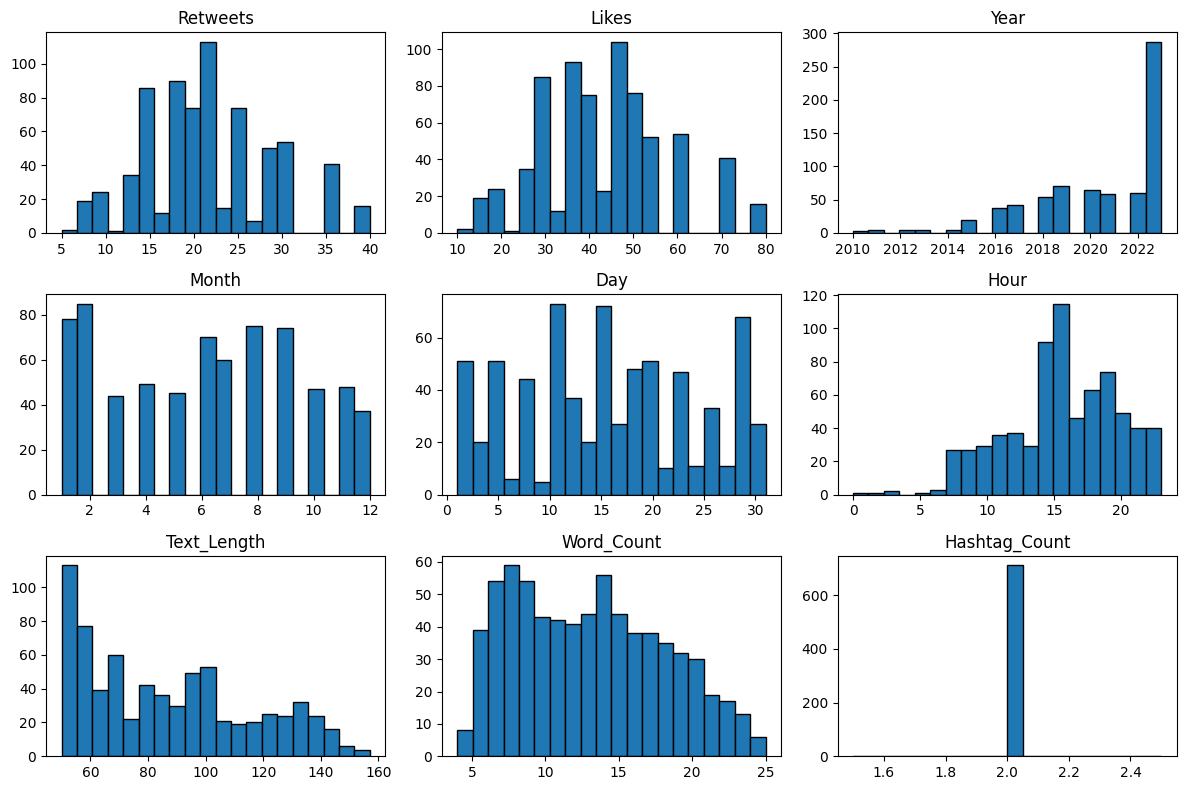

In [493]:
plt.figure(figsize=(12, 8))
df.hist(figsize=(12, 8), bins=20, edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

#### Detekcija otulier-a

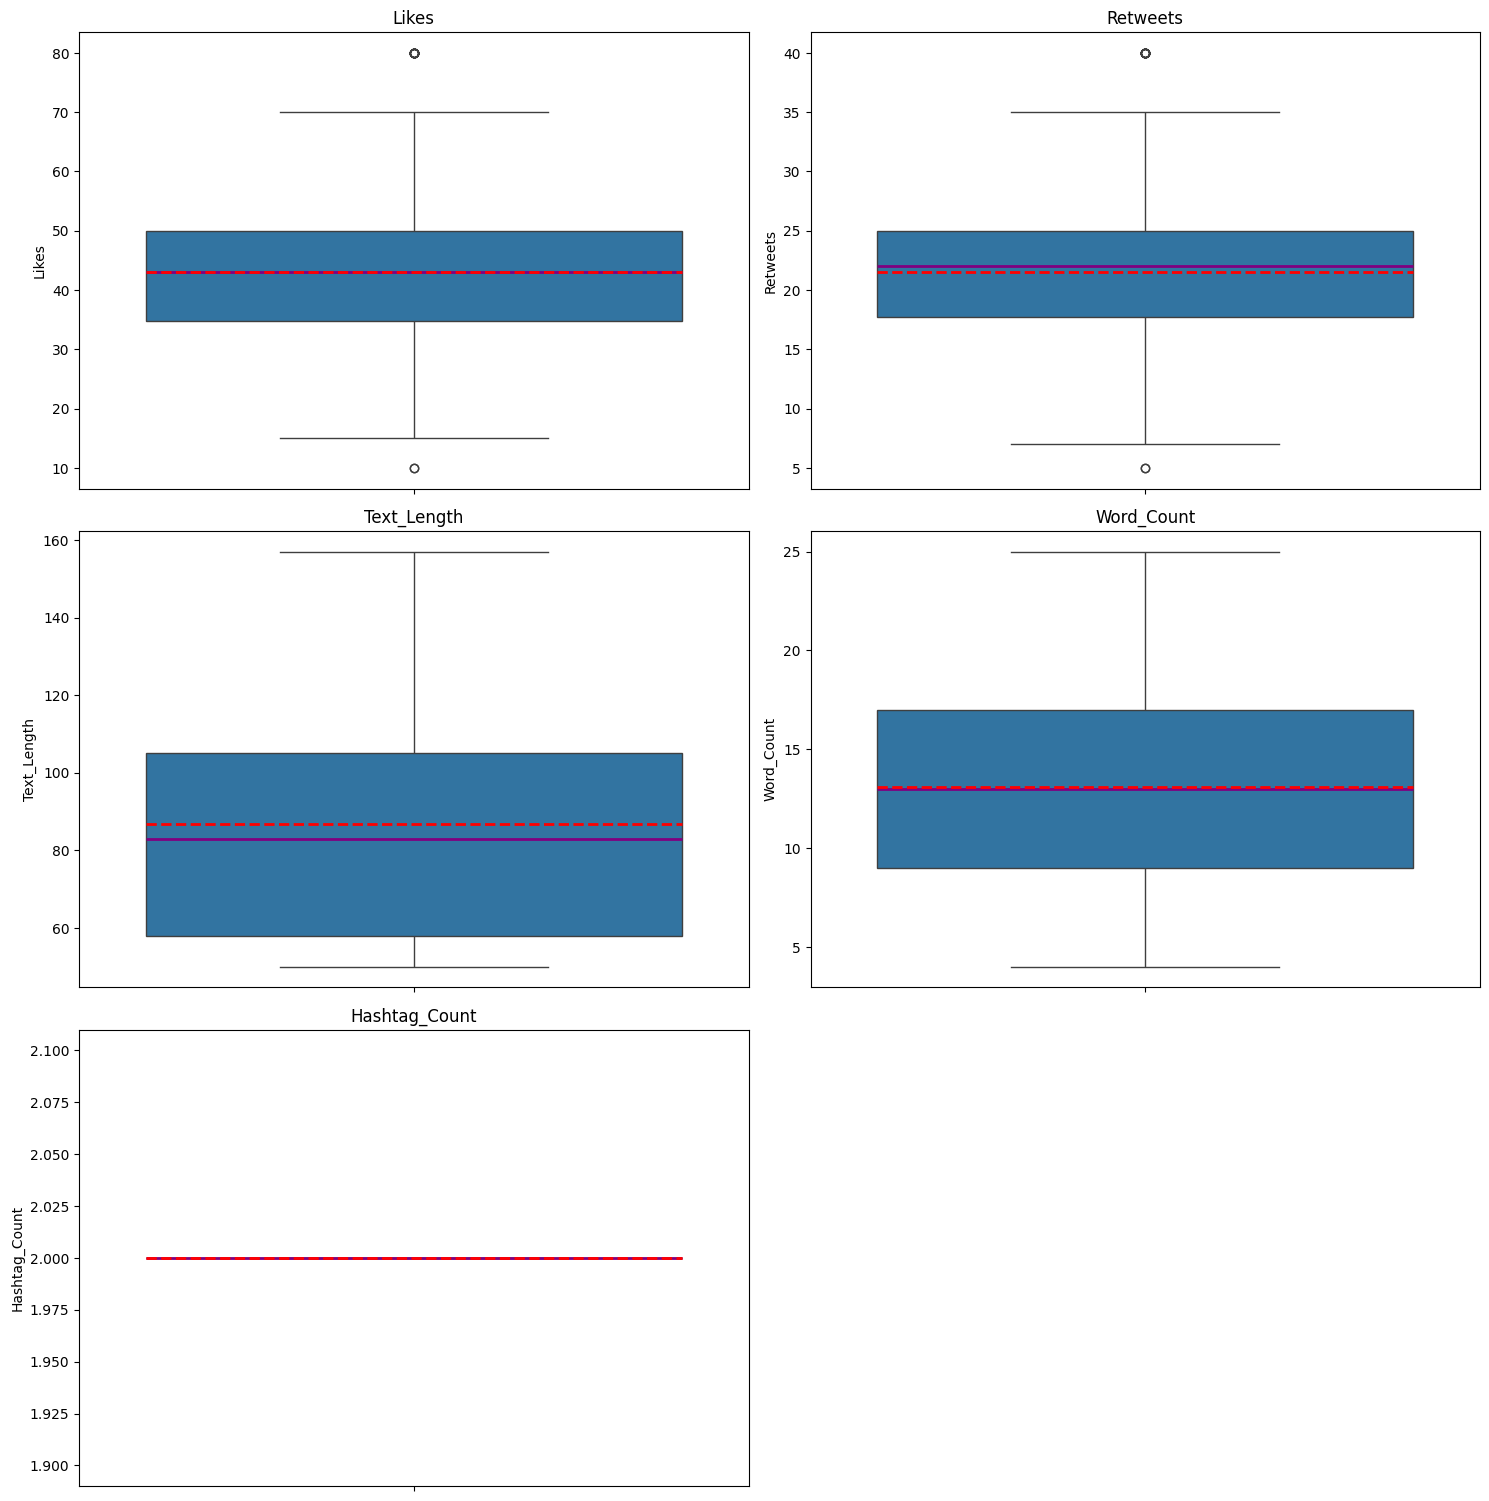

In [494]:
boxplot_columns = ['Likes', 'Retweets', 'Text_Length', 'Word_Count', 'Hashtag_Count']
cols = 2 
rows = math.ceil(df.shape[1] / cols)

plt.figure(figsize=(15, 5 * rows))

for i, feature in enumerate(boxplot_columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(
        y=df[feature], 
        showmeans=True, 
        meanline=True,
        meanprops={'color': 'red', 'linewidth': 2},
        medianprops={'color': 'purple', 'linewidth': 2}
    )
    plt.title(f"{feature}")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

#### Matrica korelacije

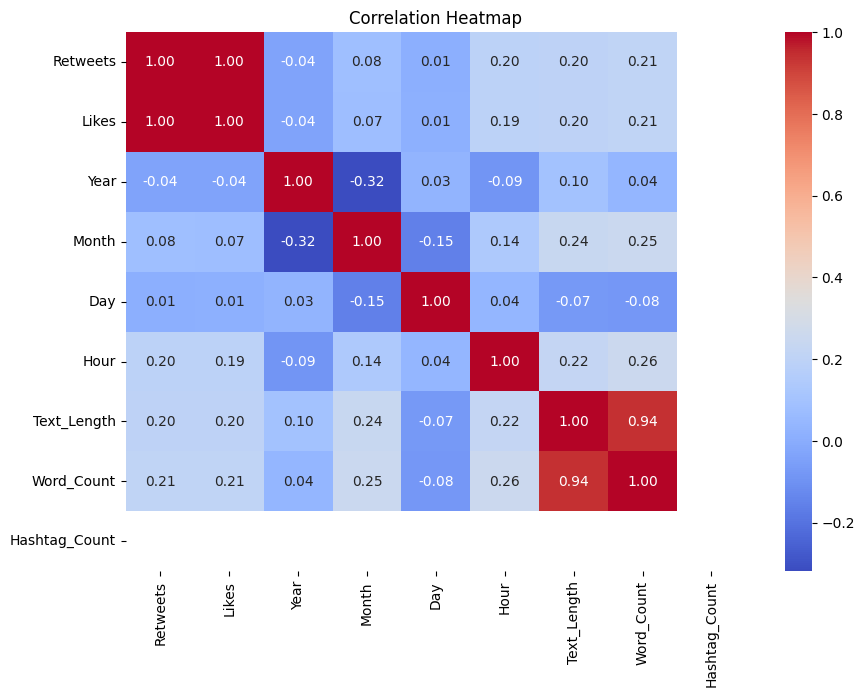

In [495]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Korelaciona analiza numeričkih atributa pokazala je savršenu korelaciju između promenljivih Likes i Retweets. Ovo ukazuje da ove promenljive nose redundantnu informaciju. S obzirom da je cilj projekta analiza sentimenta teksta, ove promenljive nisu uključene u model neuronske mreže, već su korišćene samo u deskriptivnoj analizi podataka.

# Priprema teksta

In [496]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # Uklanjanje URL-ova
    text = re.sub(r"[^a-zA-Z ]", "", text)      # Uklanjanje ne-alfa karaktera
    text = re.sub(r"@\w+", "", text)            # Uklanjanje @mention
    text = re.sub(r"#", "", text)               # Uklanjanje hashtag simbola
    text = re.sub(r"\d+", "", text)             # Uklanjanje brojeva
    text = re.sub(r"[^\w\s]", "", text)         # Uklanjanje interpunkcije
    text = re.sub(r"\s+", " ", text).strip()    # Uklanjanje visestrukih razmaka
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["Text"].apply(preprocess_text)

df[["Text", "clean_text"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lukag\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text,clean_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


# Kodiranje target promenljive

In [497]:
le = LabelEncoder()
df["Sentiment_Group_encoded"] = le.fit_transform(df["Sentiment_Group"])

print(df[["Sentiment_Group", "Sentiment_Group_encoded"]])
print(df["Sentiment_Group_encoded"].value_counts().to_string())

    Sentiment_Group  Sentiment_Group_encoded
0          Positive                        2
1          Negative                        0
2          Positive                        2
3          Positive                        2
4           Neutral                        1
..              ...                      ...
727        Positive                        2
728        Positive                        2
729        Positive                        2
730        Positive                        2
731        Positive                        2

[712 rows x 2 columns]
Sentiment_Group_encoded
2    430
0    186
1     96


# Podela skupa podataka na train i test

In [498]:
X = df["clean_text"]
y = df["Sentiment_Group_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Dimenzije trening skupa: {X_train.shape[0]}")
print(f"Dimenzije test skupa: {X_test.shape[0]}")
print("\nDistribucija klasa trening skupa:")
print(y_train.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}").to_string())
print("\nDistribucija klasa test skupa:")
print(y_test.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}").to_string())

Dimenzije trening skupa: 569
Dimenzije test skupa: 143

Distribucija klasa trening skupa:
Sentiment_Group_encoded
0    26.19%
1    13.53%
2    60.28%

Distribucija klasa test skupa:
Sentiment_Group_encoded
0    25.87%
1    13.29%
2    60.84%


# Tokenizacija

In [499]:
MAX_WORDS = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

print(X_train_pad.shape)
print(X_test_pad.shape)

(569, 50)
(143, 50)


# Metoda za evaluaciju modela

In [500]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)
    predictions = np.argmax(predictions, axis=1)

    acc = accuracy_score(y_test, predictions)

    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [501]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy plot
    axes[0].plot(history.history["accuracy"])
    axes[0].plot(history.history["val_accuracy"])
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(["train", "validation"])

    # Loss plot
    axes[1].plot(history.history["loss"])
    axes[1].plot(history.history["val_loss"])
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(["train", "validation"])

    plt.tight_layout()
    plt.show()

# Modeli

### Callback metode

In [502]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Baseline model - Simple Dense Network

In [514]:
dense_model = Sequential([
    Embedding(MAX_WORDS, 64),
    GlobalMaxPooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")
])

dense_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_14         │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [515]:
EPOCHS = 50

history_baseline = dense_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    validation_split=0.2,
    # callbacks=[early_stop_callback],
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5714 - loss: 1.0343 - val_accuracy: 0.5965 - val_loss: 0.9459
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6044 - loss: 0.9280 - val_accuracy: 0.5965 - val_loss: 0.9034
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6044 - loss: 0.9194 - val_accuracy: 0.5965 - val_loss: 0.8964
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6044 - loss: 0.8975 - val_accuracy: 0.5965 - val_loss: 0.8916
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6044 - loss: 0.8644 - val_accuracy: 0.5965 - val_loss: 0.8794
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6044 - loss: 0.8407 - val_accuracy: 0.5965 - val_loss: 0.8605
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6088 - loss: 0.7870 - val_accuracy: 0.5965 - val_loss: 0.8400
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6352 - loss: 0.7235 - val_accuracy: 0.6053 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 0.7832167832167832

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        37
           1       0.60      0.32      0.41        19
           2       0.78      0.93      0.85        87

    accuracy                           0.78       143
   macro avg       0.75      0.64      0.67       143
weighted avg       0.78      0.78      0.77       143



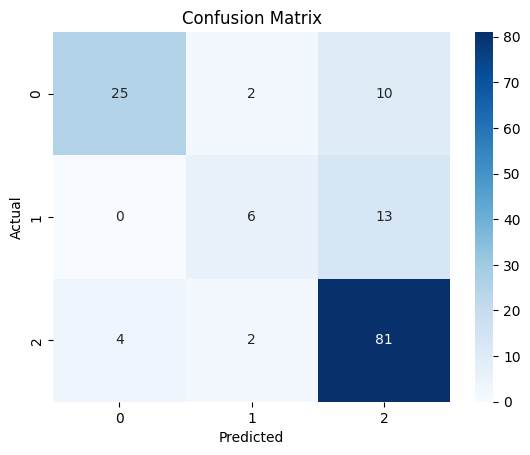

In [516]:
evaluate_model(dense_model, X_test_pad, y_test)

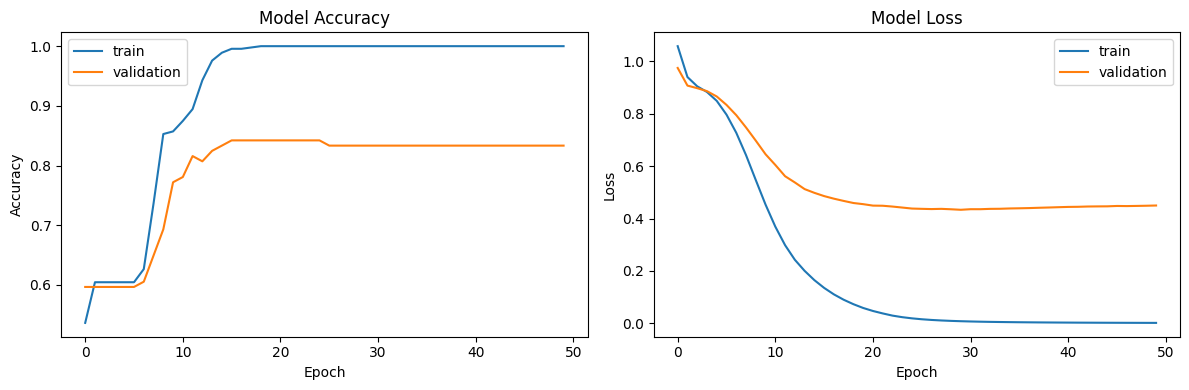

In [506]:
plot_training_history(history_baseline)

## LSTM Network

In [507]:
lstm_model = Sequential([
    Embedding(MAX_WORDS, 128),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [508]:
EPOCHS = 50

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    validation_split=0.2,
    # callbacks=[early_stop_callback],
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5736 - loss: 1.0091 - val_accuracy: 0.5965 - val_loss: 0.9244
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6022 - loss: 0.9504 - val_accuracy: 0.5965 - val_loss: 0.9316
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6044 - loss: 0.9386 - val_accuracy: 0.5965 - val_loss: 0.9148
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6044 - loss: 0.9506 - val_accuracy: 0.5965 - val_loss: 0.9229
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6044 - loss: 0.9477 - val_accuracy: 0.5965 - val_loss: 0.9184
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6044 - loss: 0.9460 - val_accuracy: 0.5965 - val_loss: 0.9167
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6044 - loss: 0.9676 - val_accuracy: 0.5965 - val_loss: 0.9431
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6044 - loss: 0.9439 - val_accuracy: 0.5965 - v

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
Accuracy: 0.6083916083916084

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.00      0.00      0.00        19
           2       0.61      1.00      0.76        87

    accuracy                           0.61       143
   macro avg       0.20      0.33      0.25       143
weighted avg       0.37      0.61      0.46       143



c:\projects\machine-learning-projects\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\projects\machine-learning-projects\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\projects\machine-learning-projects\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

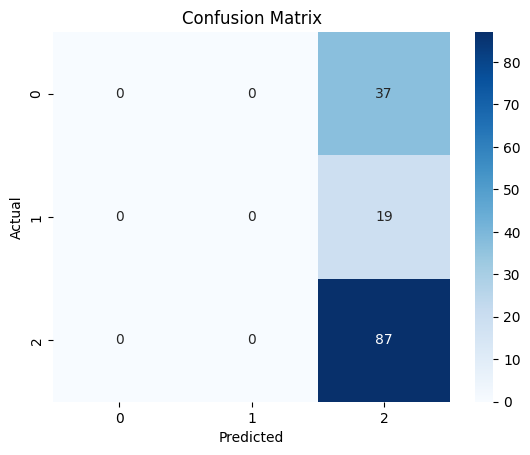

In [509]:
evaluate_model(lstm_model, X_test_pad, y_test)

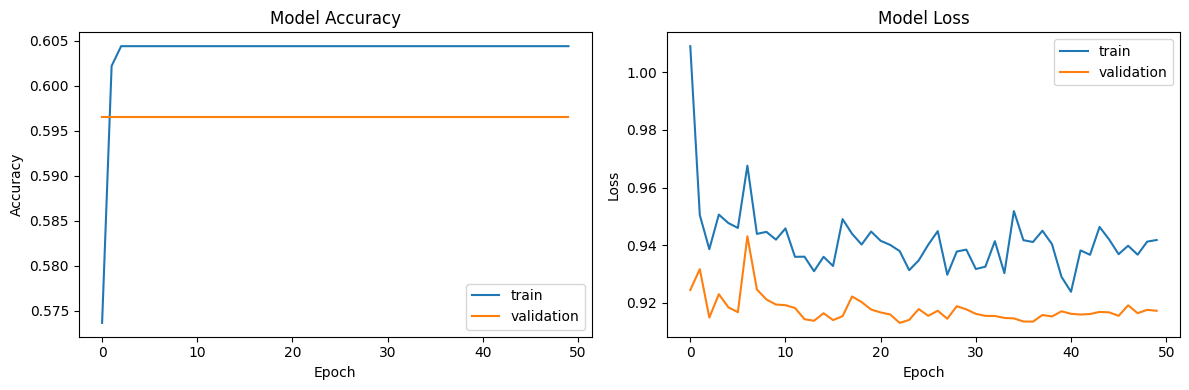

In [510]:
plot_training_history(history_lstm)

## CNN

In [511]:
cnn_model = Sequential([
    Embedding(MAX_WORDS, 128),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    epochs=50,
    validation_split=0.2,
    # callbacks=[early_stop_callback],
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5341 - loss: 1.0230 - val_accuracy: 0.5965 - val_loss: 0.9143
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5978 - loss: 0.9507 - val_accuracy: 0.5965 - val_loss: 0.9213
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.8959 - val_accuracy: 0.5965 - val_loss: 0.8953
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6132 - loss: 0.8564 - val_accuracy: 0.5965 - val_loss: 0.8620
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6484 - loss: 0.7200 - val_accuracy: 0.6053 - val_loss: 0.7913
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7516 - loss: 0.5618 - val_accuracy: 0.7018 - val_loss: 0.6723
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8484 - loss: 0.3899 - val_accuracy: 0.7544 - val_loss: 0.5743
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9121 - loss: 0.2340 - val_accuracy: 0.8070 - v

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Accuracy: 0.7692307692307693

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.62      0.77        37
           1       0.43      0.16      0.23        19
           2       0.74      0.97      0.84        87

    accuracy                           0.77       143
   macro avg       0.72      0.58      0.61       143
weighted avg       0.77      0.77      0.74       143



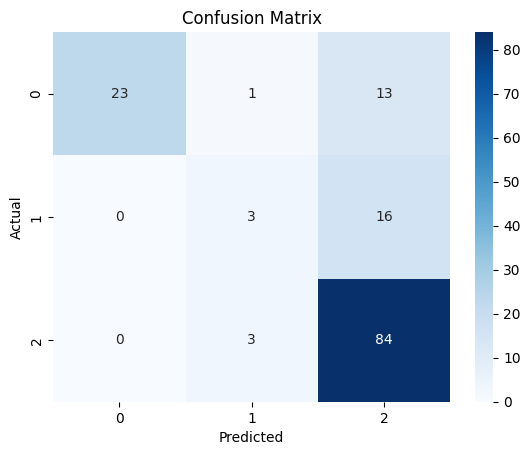

In [512]:
evaluate_model(cnn_model, X_test_pad, y_test)

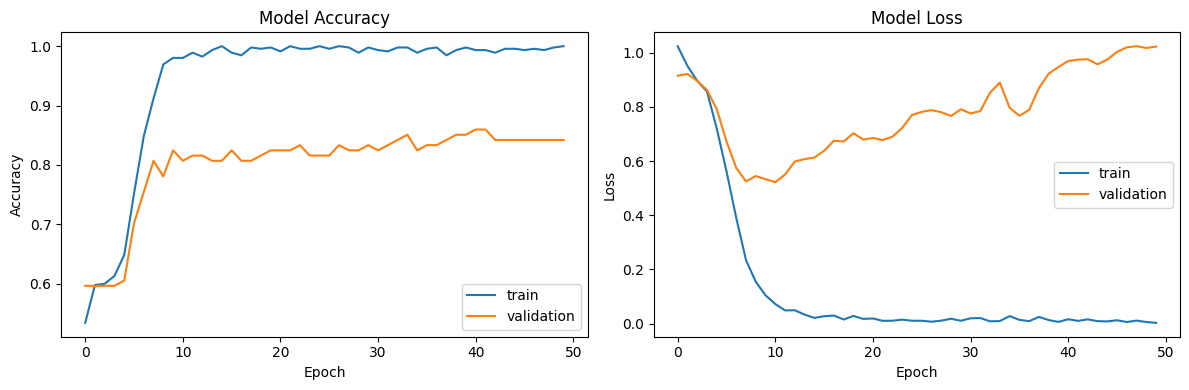

In [513]:
plot_training_history(history_cnn)

Neuronske mreže optimizuju loss funkciju, na koju utiče frekvencija klasa. Ako se klasa pojavljuje češće, mreža minimizira gubitak tako što češće predviđa tu klasu. U ovom slučaju to znači da ako model svaki put predviđa klasu 2 (Positive), on već postiže _Accuracy ≈ 60%_ bez učenja bilo kakvih smislenih obrazaca. Na ovaj način nailazimo na problem pristrasnosti većinske klase (_majority class bias problem_).

Ovaj problem se može videti i na osnovu 